# Installation

In [ ]:
!pip install pykeen

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 730.3/730.3 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 112.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Import libraries

In [ ]:
import pykeen
import pykeen.datasets
from pykeen.regularizers import LpRegularizer
from pykeen.models import TransE
from pykeen.optimizers import Adam
from pykeen.losses import MarginRankingLoss
from pykeen.training import SLCWATrainingLoop
from pykeen.sampling import BasicNegativeSampler
from pykeen.evaluation import RankBasedEvaluator
from pykeen.pipeline import pipeline
from pykeen.hpo import hpo_pipeline

INFO:pykeen.utils:Using opt_einsum


# Dataset Loading

In [ ]:
dataset = pykeen.datasets.Nations()

In [ ]:
print(f"Number of training triples: {len(dataset.training.mapped_triples)}")
print(f"Number of validation triples: {len(dataset.validation.mapped_triples)}")
print(f"Number of testing triples: {len(dataset.testing.mapped_triples)}")

Number of training triples: 1592
Number of validation triples: 199
Number of testing triples: 201


In [ ]:
print(f"First 5 training triples:\n{dataset.training.mapped_triples[:5]}")

First 5 training triples:
tensor([[ 0,  3,  2],
        [ 0,  3,  3],
        [ 0,  3, 10],
        [ 0,  3, 13],
        [ 0,  4, 11]])


# Model Training

Lets setup all the classes needed for training!

In [ ]:
regularizer = LpRegularizer(
    weight=0.01,
    p=2
)

loss = MarginRankingLoss(
    margin=1
)

model = TransE(
    triples_factory = dataset.training,
    regularizer=regularizer,
    loss=loss,
    random_seed=42,
    embedding_dim=100
)

negative_sampler = BasicNegativeSampler(
    num_negs_per_pos = 10,
    mapped_triples = dataset.training.mapped_triples
)

optimizer = Adam(
    model.parameters(),
    lr = 0.001
)

INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)


In [ ]:
training_loop = SLCWATrainingLoop(
    triples_factory = dataset.training,
    model = model,
    negative_sampler=negative_sampler,
    optimizer = optimizer
)

_ = training_loop.train(
    triples_factory=dataset.training,
    num_epochs=10,
    batch_size=100
)

Training epochs on cpu:   0%|          | 0/10 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/16.0 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/16.0 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/16.0 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/16.0 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/16.0 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/16.0 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/16.0 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/16.0 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/16.0 [00:00<?, ?batch/s]

# Evaluation

In [ ]:
evaluator = RankBasedEvaluator(
    filtered=True
    )

result = evaluator.evaluate(
    model = model,
    mapped_triples=dataset.testing.mapped_triples,
    batch_size=100,
    additional_filter_triples=[
        dataset.training.mapped_triples,
        dataset.validation.mapped_triples
    ]
)


print(f"Hits@1: \t\t{result.get_metric('hits@1'): 5.3f}")
print(f"Hits@3: \t\t{result.get_metric('hits@3'): 5.3f}")
print(f"Hits@5: \t\t{result.get_metric('hits@5'): 5.3f}")
print(f"Hits@10: \t\t{result.get_metric('hits@10'): 5.3f}")
print(f"Mean Reciprocal Rank:  \t{result.get_metric('mean_reciprocal_rank'): 5.3f}")
print(f"Mean Rank:  \t\t{result.get_metric('mean_rank'): 5.3f}")

Evaluating on cpu:   0%|          | 0.00/201 [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.10s seconds


Hits@1: 		 0.000
Hits@3: 		 0.540
Hits@5: 		 0.759
Hits@10: 		 0.970
Mean Reciprocal Rank:  	 0.323
Mean Rank:  		 4.095


# Pipelines

In [ ]:
result = pipeline(
    dataset = "Nations",

    model = "TransE",
    model_kwargs=dict(
        embedding_dim = 100
    ),

    training_loop="sLCWA",

    optimizer="adam",
    optimizer_kwargs=dict(
        lr = 0.001
    ),

    negative_sampler="basic",
    negative_sampler_kwargs=dict(
        num_negs_per_pos = 10
    ),

    evaluator="RankBasedEvaluator",

    regularizer="LpRegularizer",
    regularizer_kwargs=dict(
        p=2,
        weight = 0.01
    )
)

print(f"Hits@1: \t\t{result.get_metric('hits@1'): 5.3f}")
print(f"Hits@3: \t\t{result.get_metric('hits@3'): 5.3f}")
print(f"Hits@5: \t\t{result.get_metric('hits@5'): 5.3f}")
print(f"Hits@10: \t\t{result.get_metric('hits@10'): 5.3f}")
print(f"Mean Reciprocal Rank:  \t{result.get_metric('mean_reciprocal_rank'): 5.3f}")
print(f"Mean Rank:  \t\t{result.get_metric('mean_rank'): 5.3f}")


result.save_to_directory("results")

INFO:pykeen.datasets.utils:Loading cached preprocessed dataset from file:///root/.data/pykeen/datasets/nations/cache/47DEQpj8HBSa-_TImW-5JCeuQeRkm5NM
INFO:pykeen.triples.triples_factory:Loading from file:///root/.data/pykeen/datasets/nations/cache/47DEQpj8HBSa-_TImW-5JCeuQeRkm5NM/training
INFO:pykeen.triples.triples_factory:Loading from file:///root/.data/pykeen/datasets/nations/cache/47DEQpj8HBSa-_TImW-5JCeuQeRkm5NM/testing
INFO:pykeen.triples.triples_factory:Loading from file:///root/.data/pykeen/datasets/nations/cache/47DEQpj8HBSa-_TImW-5JCeuQeRkm5NM/validation
INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)


Training epochs on cpu:   0%|          | 0/5 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/7.00 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/7.00 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/7.00 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/7.00 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/7.00 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/201 [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.11s seconds
INFO:pykeen.triples.triples_factory:Stored TriplesFactory(num_entities=14, num_relations=55, create_inverse_triples=False, num_triples=1592, path="/usr/local/lib/python3.11/dist-packages/pykeen/datasets/nations/train.txt") to file:///content/results/training_triples
INFO:pykeen.pipeline.api:Saved to directory: /content/results


Hits@1: 		 0.000
Hits@3: 		 0.460
Hits@5: 		 0.669
Hits@10: 		 0.945
Mean Reciprocal Rank:  	 0.290
Mean Rank:  		 4.706


# Visualize Learned Embeddings

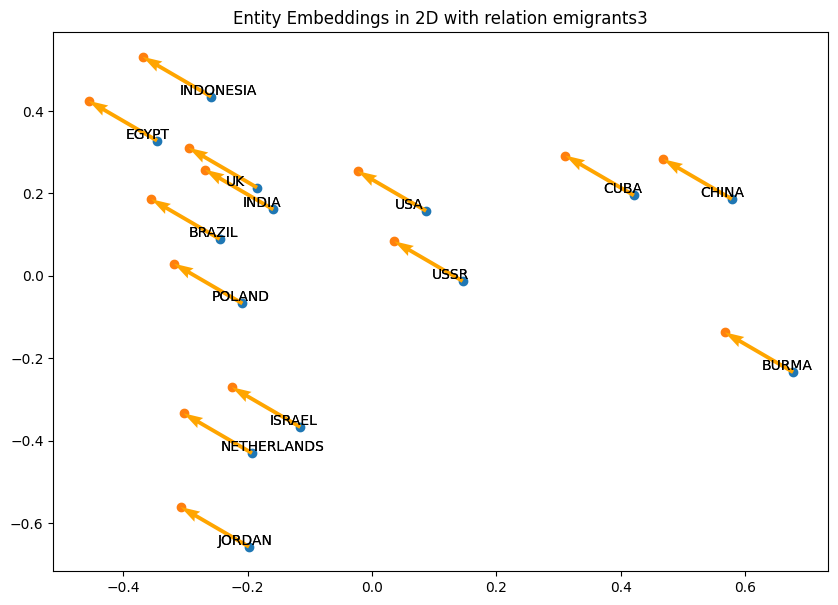

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

model = result.model

RELATION_SHOW_ID = 15

entity_embeddings = model.entity_representations[0]().detach().numpy()
relation_embeddings = model.relation_representations[0]().detach().numpy()

prediction_embeddings = entity_embeddings + relation_embeddings[RELATION_SHOW_ID]
entity_names = {v:k for k,v in dataset.entity_to_id.items()}
relation_names = {v:k for k,v in dataset.relation_to_id.items()}


pca = PCA(n_components=2)
entity_embeddings_plot = pca.fit_transform(entity_embeddings)
prediction_embeddings_plot = pca.transform(prediction_embeddings)

quiver_data = prediction_embeddings_plot - entity_embeddings_plot

plt.figure(figsize=(10,7))
plt.title(f"Entity Embeddings in 2D with relation {relation_names[RELATION_SHOW_ID]}")
plt.scatter(entity_embeddings_plot[:,0], entity_embeddings_plot[:,1], label='Entities')
plt.scatter(prediction_embeddings_plot[:,0], prediction_embeddings_plot[:,1], label="Predicted Entity")

for i, _ in enumerate(entity_embeddings_plot):
    plt.annotate(
        text=entity_names[i].upper(),
        xy=(entity_embeddings_plot[i,0] - 0.05, entity_embeddings_plot[i,1] + 0.005),
        fontsize=10
    )

for i, _ in enumerate(entity_embeddings_plot):
    plt.annotate(
        text=entity_names[i].upper(),
        xy=(entity_embeddings_plot[i,0] - 0.05, entity_embeddings_plot[i,1] + 0.005),
        fontsize=10
    )
    plt.quiver(entity_embeddings_plot[i,0], entity_embeddings_plot[i,1], quiver_data[i,0], quiver_data[i,1], angles='xy', scale_units='xy', scale=1, color='orange', width=0.005 )


# Hyperparameters Optimization

In [ ]:
result = hpo_pipeline(
    n_trials=3,
    sampler='random',
    dataset=dataset,

    epochs=50,


    model='transe',
    model_kwargs_ranges=dict(
        embedding_dim=dict(type=int, low=2, high=5, q=1),
        entity_initializer=dict(type='categorical', choices=[
            'xavier_uniform',
            'xavier_uniform_norm',
            'uniform',
    ])),



    optimizer='adam',

    loss='marginranking',
    loss_kwargs_ranges = dict(
        margin=dict(type=float, low=1, high=2),
    ),

    training_loop='slcwa',


    evaluator='RankBasedEvaluator',
    evaluator_kwargs=dict(filtered=True),
    evaluation_kwargs=dict(batch_size=4),


    stopper='early',
    stopper_kwargs=dict(
        frequency=5,
        patience=2,
        relative_delta=0.002,
        ),


    negative_sampler='basic',
    device='cpu',  # Use 'cpu' or 'cuda'
)

[I 2025-05-12 13:20:00,620] A new study created in memory with name: no-name-7a7c518a-5b98-4b16-83bb-7d813d14d842
INFO:pykeen.hpo.hpo:Using model: <class 'pykeen.models.unimodal.trans_e.TransE'>
INFO:pykeen.hpo.hpo:Using loss: <class 'pykeen.losses.MarginRankingLoss'>
INFO:pykeen.hpo.hpo:Using optimizer: <class 'torch.optim.adam.Adam'>
INFO:pykeen.hpo.hpo:Using training loop: <class 'pykeen.training.slcwa.SLCWATrainingLoop'>
INFO:pykeen.hpo.hpo:Using negative sampler: <class 'pykeen.sampling.basic_negative_sampler.BasicNegativeSampler'>
INFO:pykeen.hpo.hpo:Using evaluator: <class 'pykeen.evaluation.rank_based_evaluator.RankBasedEvaluator'>
INFO:pykeen.hpo.hpo:Attempting to maximize both.realistic.inverse_harmonic_mean_rank
INFO:pykeen.hpo.hpo:Filter validation triples when testing: True
INFO:pykeen.pipeline.api:Using device: cpu
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.stoppers.ea

Training epochs on cpu:   0%|          | 0/50 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/4.00 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/4.00 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/4.00 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/25.0 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/25.0 [00:00<?, ?batch/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.08s seconds
INFO:pykeen.stoppers.early_stopping:Stopping early at epoch 30. The best result 0.9899497487437185 occurred at epoch 20.
INFO:pykeen.stoppers.early_stopping:Re-loading weights from best epoch from /root/.data/pykeen/checkpoints/best-model-weights-ad2cd242-49fc-4836-8f0d-8cd3febe667f.pt


Evaluating on cpu:   0%|          | 0.00/199 [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.18s seconds
[I 2025-05-12 13:20:37,714] Trial 2 finished with value: 0.4372349679470062 and parameters: {'model.embedding_dim': 4, 'model.scoring_fct_norm': 1, 'model.entity_initializer': 'xavier_uniform', 'loss.margin': 1.32136343507617, 'optimizer.lr': 0.04973512052599338, 'negative_sampler.num_negs_per_pos': 13, 'training.batch_size': 64}. Best is trial 1 with value: 0.4502636790275574.


In [ ]:
best_trial = result.study.best_trial

best_trial_params = {}
for param_name, param_value in best_trial.params.items():
    print(f"{param_name}: {param_value}")
    best_trial_params[param_name] = param_value

model.embedding_dim: 2
model.scoring_fct_norm: 2
model.entity_initializer: xavier_uniform_norm
loss.margin: 1.798736465778221
optimizer.lr: 0.09223574213417347
negative_sampler.num_negs_per_pos: 3
training.batch_size: 256
